# Notebook 06 - Unsat-core feedback ablation

**Sprint:** S4 (Formal Verification & Discovery)
**Roadmap task:** s4-7

## Scientific gate

> With feedback -> higher feasible discovery rate at equal budget (H9).

## What this notebook measures

Two arms of the same mutation-based discovery loop:

- **Random arm:** picks operator and target uniformly from the applicable set at each step.
- **Feedback arm:** reads the ConflictProneTable produced by the s4-4 attribution and biases the mutation toward conflict-prone features with probability equal to the configured conflict_probability.

Both arms start from the same initial architecture, run for the same maximum step budget, and use independent RNG streams seeded for reproducibility. The experiment is repeated across many trials.

The reported quantity is the fraction of trials that have reached SAT by step k. H9 asserts that the feedback arm has a higher feasible discovery rate at equal budget, which corresponds to a lower survival curve at every step.

## Synthetic infeasibility

A single designated bottleneck link, forced to be a Laser_Link at the start, is the sole source of infeasibility. A constraint family tagged to that link requires x >= 10 and conflicts with a fixed x <= 5. Every other link and node is unconstrained by the encoding. The loop is UNSAT for as long as the bottleneck link remains a Laser_Link, and SAT once the mutator changes it or removes it.


In [1]:
%matplotlib inline

import random
import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "backend"))

import matplotlib.pyplot as plt
import z3

from app.discovery.attribution import (
    ConflictProneTable,
    FeatureConstraint,
    FeatureKind,
    GrammarFeature,
    attribute_and_mark,
)
from app.discovery.generator import (
    LINK_PARAM_RANGES,
    GeneratorConfig,
    generate_architecture,
)
from app.discovery.grammar import (
    Architecture,
    LinkInstance,
    Terminal,
)
from app.discovery.mutation import (
    MutationConfig,
    mutate_conflict_directed,
    mutate_random,
)

print(f"z3 version: {z3.get_version_string()}")
print(f"python:     {sys.version.split()[0]}")


z3 version: 5.1.0
python:     3.12.14


## Helper functions

The helpers below construct a forced-bottleneck architecture, build the synthetic constraint system, and run one trial of the discovery loop.


In [2]:
def make_initial_architecture(seed):
    gen_config = GeneratorConfig(
        min_nodes=6, max_nodes=8, max_links=12, seed=seed
    )
    arch = generate_architecture(gen_config)
    first = arch.links[0]
    rng = random.Random(seed + 500_000)
    new_params = {
        name: rng.uniform(lo, hi)
        for name, (lo, hi) in LINK_PARAM_RANGES[Terminal.LASER_LINK].items()
    }
    forced = LinkInstance(
        link_id=first.link_id,
        kind=Terminal.LASER_LINK,
        source_id=first.source_id,
        target_id=first.target_id,
        params=new_params,
    )
    new_links = (forced, *arch.links[1:])
    return Architecture(nodes=arch.nodes, links=new_links), forced.link_id


def make_constraints(arch, bottleneck_id):
    x = z3.Real("x_ablation")
    constraints = [
        FeatureConstraint(
            family_name="ground_max",
            expression=x <= 5.0,
            features=frozenset({
                GrammarFeature(
                    FeatureKind.NODE_TYPE, Terminal.GROUND_STATION.value
                ),
            }),
        ),
    ]
    bottleneck = next(
        (ln for ln in arch.links if ln.link_id == bottleneck_id), None
    )
    if bottleneck is not None and bottleneck.kind == Terminal.LASER_LINK:
        constraints.append(
            FeatureConstraint(
                family_name="bottleneck_requires_high",
                expression=x >= 10.0,
                features=frozenset({
                    GrammarFeature(
                        FeatureKind.LINK_INSTANCE, bottleneck.link_id
                    ),
                    GrammarFeature(
                        FeatureKind.LINK_TYPE, bottleneck.kind.value
                    ),
                }),
            )
        )
    return tuple(constraints)


def run_trial(arch, bottleneck_id, mode, max_steps, rng, config):
    for step in range(max_steps):
        table = ConflictProneTable()
        constraints = make_constraints(arch, bottleneck_id)
        attribution = attribute_and_mark(constraints, table)
        if attribution.status == "sat":
            return step
        if mode == "random":
            arch = mutate_random(arch, rng, config)
        else:
            arch = mutate_conflict_directed(arch, table, rng, config)
    return None


print("Helpers defined.")


Helpers defined.


## Experiment configuration


In [3]:
N_TRIALS = 50
MAX_STEPS = 12
MUTATION_CONFIG = MutationConfig()

print(f"Trials per arm:   {N_TRIALS}")
print(f"Step budget:      {MAX_STEPS}")
print(f"Conflict p:       {MUTATION_CONFIG.conflict_probability}")


Trials per arm:   50
Step budget:      12
Conflict p:       0.85


## Run both arms


In [4]:
conflict_steps = []
random_steps = []

for trial in range(N_TRIALS):
    initial_seed = 7000 + trial
    initial_arch, bottleneck_id = make_initial_architecture(initial_seed)

    rng_c = random.Random(9000 + trial)
    s_c = run_trial(
        initial_arch, bottleneck_id, "conflict",
        MAX_STEPS, rng_c, MUTATION_CONFIG,
    )
    conflict_steps.append(s_c)

    rng_r = random.Random(11_000 + trial)
    s_r = run_trial(
        initial_arch, bottleneck_id, "random",
        MAX_STEPS, rng_r, MUTATION_CONFIG,
    )
    random_steps.append(s_r)


def summarize(name, steps):
    reached = [s for s in steps if s is not None]
    rate = len(reached) / len(steps)
    mean = sum(reached) / len(reached) if reached else float("nan")
    print(f"{name:12s}: reached = {len(reached)}/{len(steps)} "
          f"({rate*100:.0f}%), mean steps = {mean:.2f}")


summarize("random", random_steps)
summarize("conflict", conflict_steps)


random      : reached = 35/50 (70%), mean steps = 5.91
conflict    : reached = 49/50 (98%), mean steps = 2.27


## Survival curves

For each step k, count how many trials in each arm have not yet reached SAT. A lower survival curve means faster convergence.


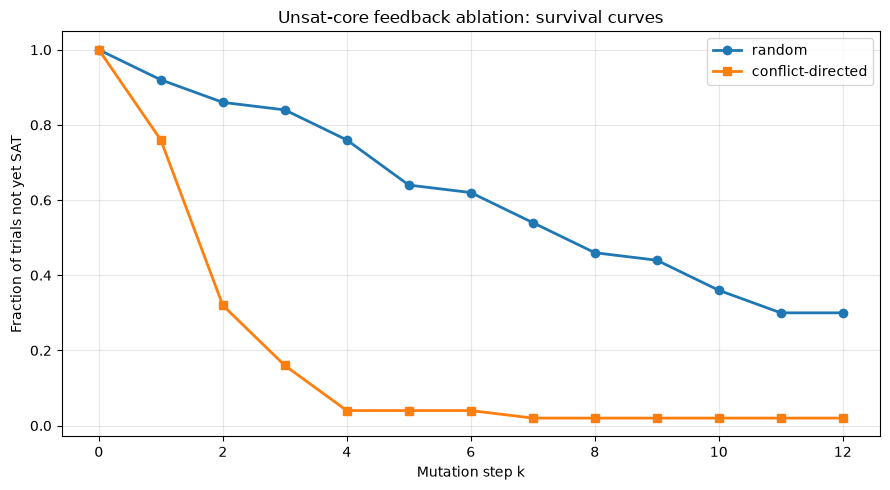

k= 0  random = 1.000  conflict = 1.000
k= 2  random = 0.860  conflict = 0.320
k= 4  random = 0.760  conflict = 0.040
k= 6  random = 0.620  conflict = 0.040
k= 8  random = 0.460  conflict = 0.020
k=10  random = 0.360  conflict = 0.020


In [5]:
steps_axis = list(range(MAX_STEPS + 1))


def survival(steps):
    out = []
    for k in steps_axis:
        survived = sum(1 for s in steps if s is None or s > k)
        out.append(survived / len(steps))
    return out


surv_random = survival(random_steps)
surv_conflict = survival(conflict_steps)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(steps_axis, surv_random, marker="o", linewidth=2, label="random")
ax.plot(steps_axis, surv_conflict, marker="s", linewidth=2, label="conflict-directed")
ax.set_xlabel("Mutation step k")
ax.set_ylabel("Fraction of trials not yet SAT")
ax.set_title("Unsat-core feedback ablation: survival curves")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

for k in [0, 2, 4, 6, 8, 10]:
    print(f"k={k:2d}  random = {surv_random[k]:.3f}  "
          f"conflict = {surv_conflict[k]:.3f}")


## Gate

H9: with feedback, the discovery loop reaches a feasible architecture at a higher rate at equal budget. In the survival-curve view, that is a strictly lower survival fraction at every step after step 0.

The check below asserts the feedback arm's survival fraction is no greater than the random arm's at every step, and strictly less at some step.


In [6]:
assert all(
    surv_conflict[k] <= surv_random[k] + 1e-9
    for k in steps_axis
), "Feedback arm has a higher survival fraction at some step"

strictly_better = any(
    surv_conflict[k] < surv_random[k] - 1e-9
    for k in steps_axis
)
assert strictly_better, "Feedback arm never strictly dominates the random arm"

print("GATE: PASS")
print()
print("Notebook 06 summary")
print("=" * 60)
summarize("random", random_steps)
summarize("conflict", conflict_steps)


GATE: PASS

Notebook 06 summary
random      : reached = 35/50 (70%), mean steps = 5.91
conflict    : reached = 49/50 (98%), mean steps = 2.27
